# Build dataset

Assembles the point-in-time S&P 500 panel — prices, FINRA short volume/interest,
SEC fundamentals, FRED macro sensitivities — runs the data-quality checks, and
caches everything to `Data/` as parquet.

Needs a `FRED_API_KEY` in the environment (free from fred.stlouisfed.org). The
FINRA/SEC pulls are slow and rate-limited: run this once, then work off the
cached files.


In [3]:
import warnings, time
import numpy as np, pandas as pd
import yfinance as yf
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 150)

In [ ]:
# This notebook lives in Notebooks/ — hop up to the repo root so that
# Utils imports and Data/ paths resolve.
import os
if os.path.basename(os.getcwd()) == "Notebooks":
    os.chdir("..")
print("working dir:", os.getcwd())


In [5]:
from Utils.alpha_data_loaders import (load_sp500_csv, get_universe_from_csv, download_sp500_tables, survivorship_complete_universe,
    build_membership_panel, download_finra_short_volume, download_finra_short_interest, build_membership_panel_from_csv,
    align_short_interest_pit, build_pit_fundamental_panel)
from Utils.features import (build_price_panel, add_cross_sectional_target, merge_alt_data,
    finalize_dataset, coverage_report)
from Utils.fred_features import (load_fred_pit, make_macro_factor_changes, add_macro_sensitivities, check_macro_features,
                                 FRED_MARKET_SERIES, MACRO_BETA_FEATURES)
from Utils.walkforward import run_walkforward
from Utils.forecast_combination import model_ic_table, ic_weighted
from Utils.neutralize import residualize_prediction, exposure_report
from Utils.portfolio import build_weights, backtest, print_pnl, paper_trade_step
from Utils.models import make_model_factories
from Utils.tune_gbrt import tune_gbrt



START_DATE, END_DATE = "2020-06-01", "2026-06-01"
WF = dict(train_min=378, test_size=21, step=21, label_horizon=5, embargo=2,expanding=True)

In [7]:
# 1. Use the CSV for TRUE point-in-time membership and universe
sp500_history = load_sp500_csv("Data/S&P 500 Historical Components & Changes (Updated).csv")
universe = get_universe_from_csv(sp500_history)

# 2. Keep Wikipedia strictly to grab current GICS Sector metadata for the risk model
current, _ = download_sp500_tables()
sp500_meta = current.rename(columns={"gics_sector": "GICS Sector"})[["symbol", "GICS Sector"]]

# 3. Download Prices & Market benchmark as before
md_raw = yf.download(universe, start=START_DATE, end=END_DATE, auto_adjust=True,
                     group_by="ticker", progress=False, threads=True)
gspc = yf.download("^GSPC", start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
close = gspc["Close"]
close = close.iloc[:, 0] if isinstance(close, pd.DataFrame) else close
market = pd.DataFrame({"date": pd.to_datetime(gspc.index), "market_ret_1d": close.pct_change().values})


ERROR:yfinance:
431 Failed downloads:
ERROR:yfinance:['DTV', 'TWTR', 'CMA', 'JP', 'XLNX', 'FTR', 'INCLF', 'RDS.A', 'CBH', 'VIAC', 'SHN', 'SRCL', 'IGT', 'ARNC', 'PDCO', 'LLL', 'TMK', 'ATGE', 'DALRQ', 'ADS', 'HCR', 'LM', 'DRE', 'BRK.B', 'HOLX', 'NLSN', 'FL', 'BGG', 'BMGCA', 'DCNAQ', 'JEC', 'LUB', 'BFO', 'STR', 'PSFT', 'FRX', 'FLIR', 'RE', 'PCH', 'TUP', 'NAV', 'AHM', 'ANTM', 'MYL', 'BIG', 'TIF', 'ACKH', 'SGID', 'CITGQ', 'CIT.A', 'DNB', 'PKI', 'ODP', 'LDW.B', 'LOR', 'GRA', 'RRD', 'ABMD', 'FRC', 'HI', 'CRR', 'TA', 'RHT', 'DAY', 'DISH', 'SNV', 'AVP', 'I', 'JNPR', 'MON', 'PX', 'CELG', 'CTB', 'CDAY', 'UN', 'HRS', 'WIN', 'X', 'UMG', 'UTX', 'SIVB', 'WFT', 'FDC', 'NRTLQ', 'MTL', 'PEAK', 'SEE', 'FII', 'SWN', 'ETFC', 'WBA', 'TMC.A', 'HPH', 'BHGE', 'COG', 'NLOK', 'CTLT', 'PARA', 'XEC', 'RYI', 'RLM', 'DWDP', 'ESV', 'WRK', 'ENDP', 'WCG', 'BBI', 'MRO', 'GIDL', 'KSU', 'RTN', 'MMC', 'K', 'HCP', 'ALXN', 'HMA', 'USHC', 'BFI', 'FI', 'NCR', 'PLL', 'VSTNQ', 'BVSN', 'MZIAQ', 'SYMC', 'ALTR', 'YRCW', 'CTL', 'CPN

In [9]:
FRED_API_KEY = os.getenv("FRED_API_KEY")

# 4. Build the price panel and define the trading grid
panel = build_price_panel(md_raw, market, tickers=universe)
panel = add_cross_sectional_target(panel, sp500_meta, target_mode="xs_demean")
grid = pd.DatetimeIndex(sorted(panel["date"].unique()))


# PIT macro levels aligned to YOUR trading grid, lagged 1 business day
fred_daily = load_fred_pit(FRED_MARKET_SERIES, START_DATE, END_DATE,
                           api_key=FRED_API_KEY, grid=grid, knowledge_lag_days=1)
macro_chg  = make_macro_factor_changes(fred_daily)

#5. Build membership panel
membership = build_membership_panel_from_csv(sp500_history, grid)

# 6. Fetch alternative data and merge
# short_vol = download_finra_short_volume(START_DATE, END_DATE, symbols=universe)
# trading_grid = pd.DatetimeIndex(sorted(short_vol["date"].unique()))
# short_int = align_short_interest_pit(
#     download_finra_short_interest(START_DATE, END_DATE, symbols=universe), trading_grid)
# fundamentals = build_pit_fundamental_panel(universe, trading_grid)

short_vol = pd.read_parquet("./Data/short_vol.parquet")
short_int = pd.read_parquet("./Data/short_int.parquet")
fundamentals = pd.read_parquet("./Data/fundamentals.parquet")


  ok WTI        (DCOILWTICO)
  ! DGS10: all-releases unavailable (Bad Request.  There are 5047 vintage dat); using get_series + lag (OK for non-revised market series).
  ok UST10Y     (DGS10)
  ok HY_SPREAD  (BAMLH0A0HYM2)
  ok USD_BROAD  (DTWEXBGS)
  ! VIXCLS: all-releases unavailable (Bad Request.  There are 3871 vintage dat); using get_series + lag (OK for non-revised market series).
  ok VIX        (VIXCLS)


In [10]:
current, changes = download_sp500_tables()
removed_tickers = set(changes["removed"].dropna())
gspc = yf.download("^GSPC", start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
close = gspc["Close"]; close = close.iloc[:,0] if isinstance(close, pd.DataFrame) else close
market = pd.DataFrame({"date": pd.to_datetime(gspc.index), "market_ret_1d": close.pct_change().values})

## 2. DATA QUALITY CHECKS — before trusting anything

For each source we check: shape, date span, duplicate `(date, symbol)` keys,
null rates, and value sanity (e.g. short_ratio in [0,1], no negative prices,
survivorship coverage). A source that fails here does not go into the model.

In [11]:
def qc(name, df, key=("date","symbol"), checks=None):
    print(f"--- {name} ---")
    print(f"  shape: {df.shape}")
    if "date" in df:
        print(f"  dates: {pd.to_datetime(df['date']).min().date()} -> {pd.to_datetime(df['date']).max().date()}")
    if all(k in df for k in key):
        dup = df.duplicated(list(key)).sum()
        print(f"  duplicate {key} rows: {dup}")
    nulls = df.isna().mean().sort_values(ascending=False)
    top = nulls[nulls > 0].head(5)
    print(f"  null-rate (top): {dict(top.round(3)) if len(top) else 'none'}")
    if checks:
        for desc, ok in checks.items():
            print(f"  check[{desc}]: {'PASS' if ok else 'FAIL'}")
    print()

# survivorship coverage
got = set(md_raw.columns.get_level_values(0)) if hasattr(md_raw.columns,"get_level_values") else set(universe)
print(f"survivorship: requested {len(universe)}, received {len(got)} "
      f"({len(got)/len(universe):.0%}); of {len(removed_tickers)} delisted, "
      f"{len(removed_tickers & got)} have data\n")

qc("short_volume", short_vol, checks={
    "short_ratio in [0,1]": short_vol["short_ratio"].between(0,1).mean() > 0.99,
    "short_volume >= 0": (short_vol["short_volume"]>=0).all()})
qc("short_interest", short_int)
qc("fundamentals", fundamentals)

survivorship: requested 1202, received 1202 (100%); of 367 delisted, 341 have data

--- short_volume ---
  shape: (886839, 7)
  dates: 2021-01-04 -> 2026-06-01
  duplicate ('date', 'symbol') rows: 0
  null-rate (top): {'short_ratio_z20': np.float64(0.016), 'short_ratio_chg5': np.float64(0.004)}
  check[short_ratio in [0,1]]: PASS
  check[short_volume >= 0]: PASS

--- short_interest ---
  shape: (244440, 6)
  dates: 2021-01-04 -> 2026-06-01
  duplicate ('date', 'symbol') rows: 0
  null-rate (top): {'short_interest': np.float64(0.356), 'avg_daily_volume': np.float64(0.356), 'short_interest_rank': np.float64(0.356), 'days_to_cover': np.float64(0.356)}

--- fundamentals ---
  shape: (859614, 7)
  dates: 2021-01-04 -> 2026-06-01
  duplicate ('date', 'symbol') rows: 0
  null-rate (top): {'eps_diluted': np.float64(0.075), 'revenue': np.float64(0.075), 'net_income': np.float64(0.07), 'equity': np.float64(0.061), 'assets': np.float64(0.056)}



## 3. Target & features

**Target:** `ret_1d_fwd − xs_mean(ret_1d_fwd)` (cross-sectional demean) — what a
dollar-neutral book earns; needs no index.

**Hygiene:** core price features must be present (else row dropped); alt features
median-filled per date + `_isna` flag; un-ranked continuous features winsorised
1/99% within date; ranks are within-date (no cross-date leakage); residual fills
use neutral constants (no global-median look-ahead).

In [12]:
datasets = [panel, membership, short_vol, short_int, fundamentals]

for df in datasets:
    if df is not None and not df.empty and 'date' in df.columns:
        # 1. Convert to pandas datetime
        df['date'] = pd.to_datetime(df['date'])
        # 2. Strip out any sneaky timezones
        if df['date'].dt.tz is not None:
            df['date'] = df['date'].dt.tz_localize(None)
        # 3. Cast firmly to datetime64[ns]
        df['date'] = df['date'].astype('datetime64[ns]')

# Merge everything using the new membership panel
panel = merge_alt_data(panel, membership, short_vol, short_int, fundamentals,
                       restrict_to_index=True)
model_df, feature_cols = finalize_dataset(panel)

print(f"model_df: {len(model_df):,} rows x {len(feature_cols)} features ")

model_df: 596,752 rows x 38 features 


In [13]:
cov, by_year = coverage_report(model_df, feature_cols)
print(cov.to_string()); by_year

                               pct_nonnull
ret_5d_rank                            1.0
ret_20d_rank                           1.0
ret_60d_rank                           1.0
ret_120d_rank                          1.0
ret_252d_rank                          1.0
vol_20d_rank                           1.0
adv20_rank                             1.0
relative_volume_rank                   1.0
volume_zscore_rank                     1.0
rsi_14                                 1.0
ma_spread                              1.0
rsi_vol                                1.0
maspread_beta                          1.0
beta_60d                               1.0
short_ratio_rank                       1.0
short_ratio_rank_isna                  1.0
short_ratio_z20                        1.0
short_ratio_z20_isna                   1.0
short_ratio_chg5                       1.0
short_ratio_chg5_isna                  1.0
short_interest_rank                    1.0
short_interest_rank_isna               1.0
days_to_cov

,ret_5d_rank,ret_20d_rank,ret_60d_rank,ret_120d_rank,ret_252d_rank,vol_20d_rank,adv20_rank,relative_volume_rank,volume_zscore_rank,rsi_14,ma_spread,rsi_vol,maspread_beta,beta_60d,short_ratio_rank,...,days_to_cover_isna,ey_rank,ey_rank_isna,leverage_rank,leverage_rank_isna,sector_Consumer Discretionary,sector_Consumer Staples,sector_Energy,sector_Financials,sector_Health Care,sector_Industrials,sector_Information Technology,sector_Materials,sector_Real Estate,sector_Utilities
_y,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2022,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2025,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2026,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


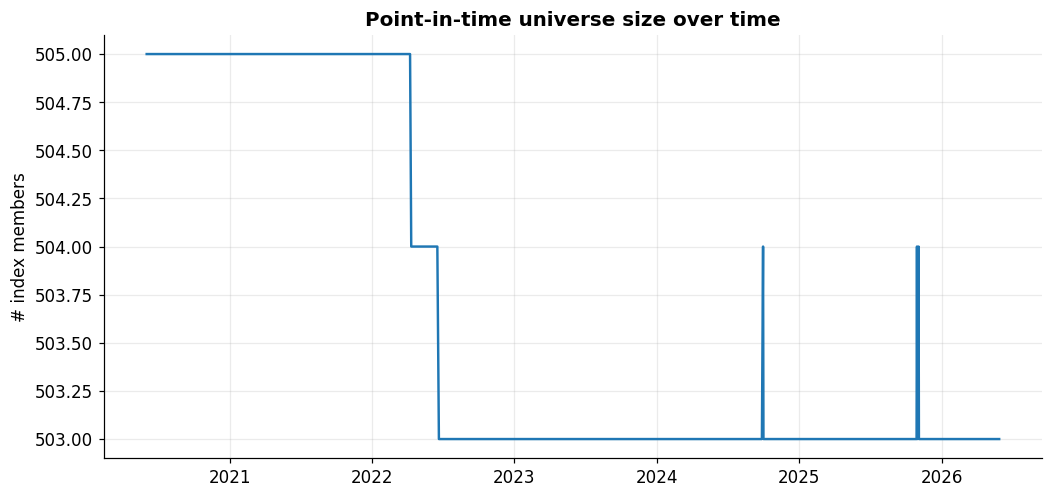

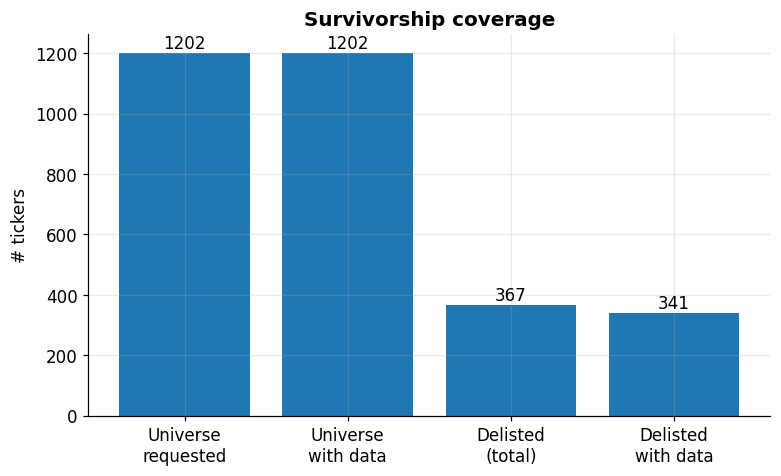

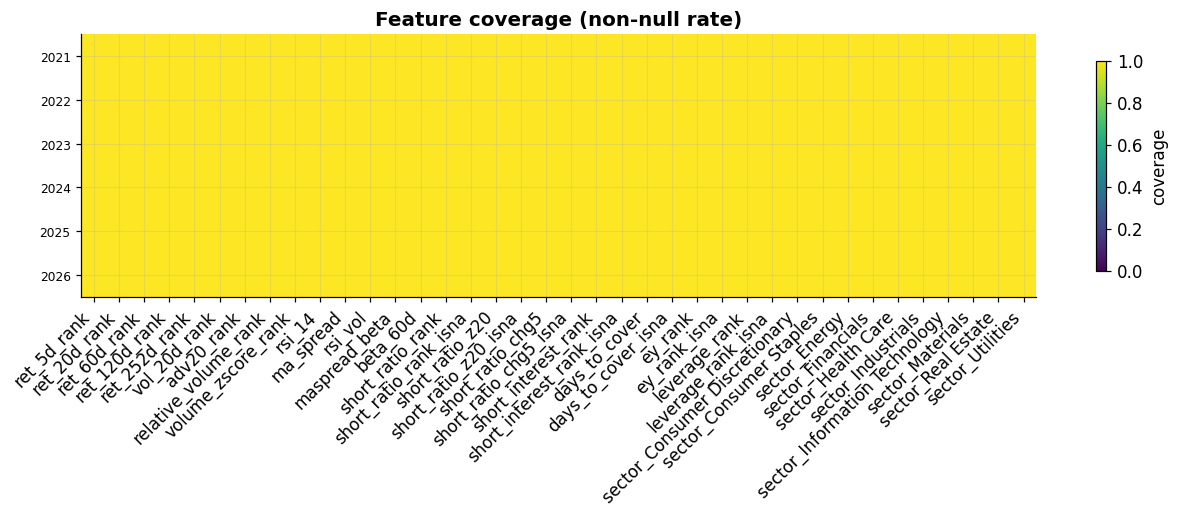

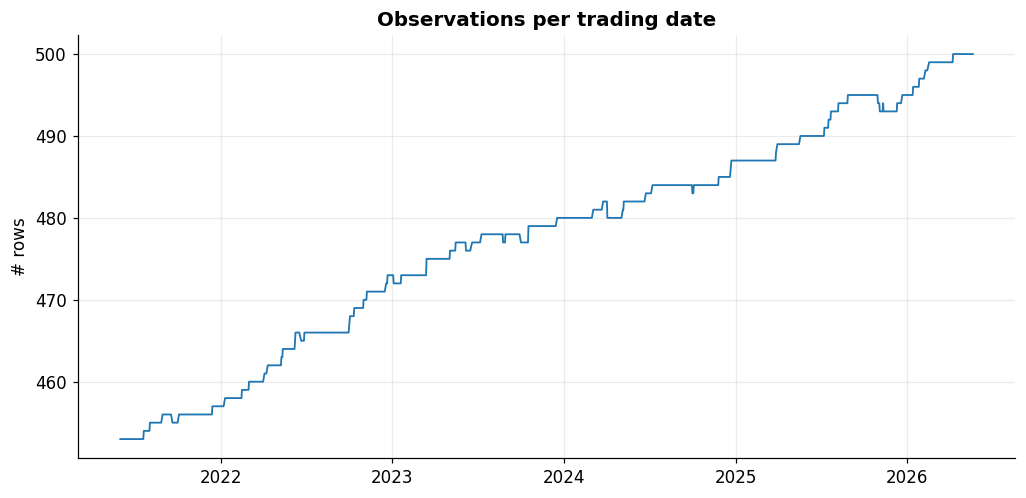

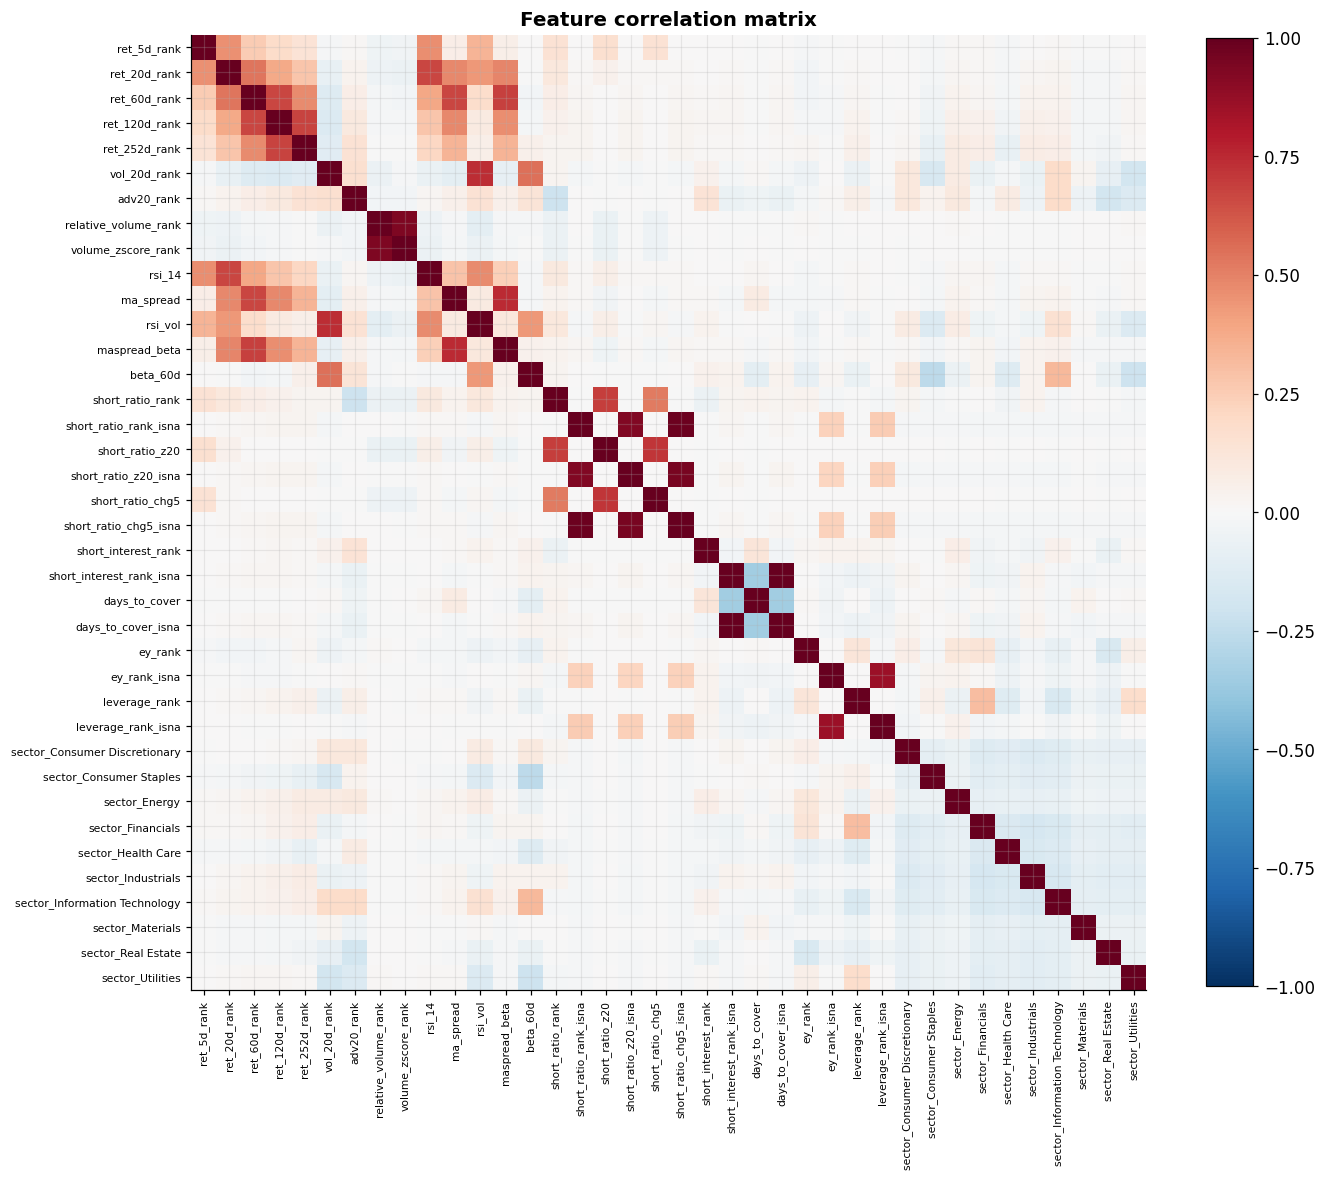

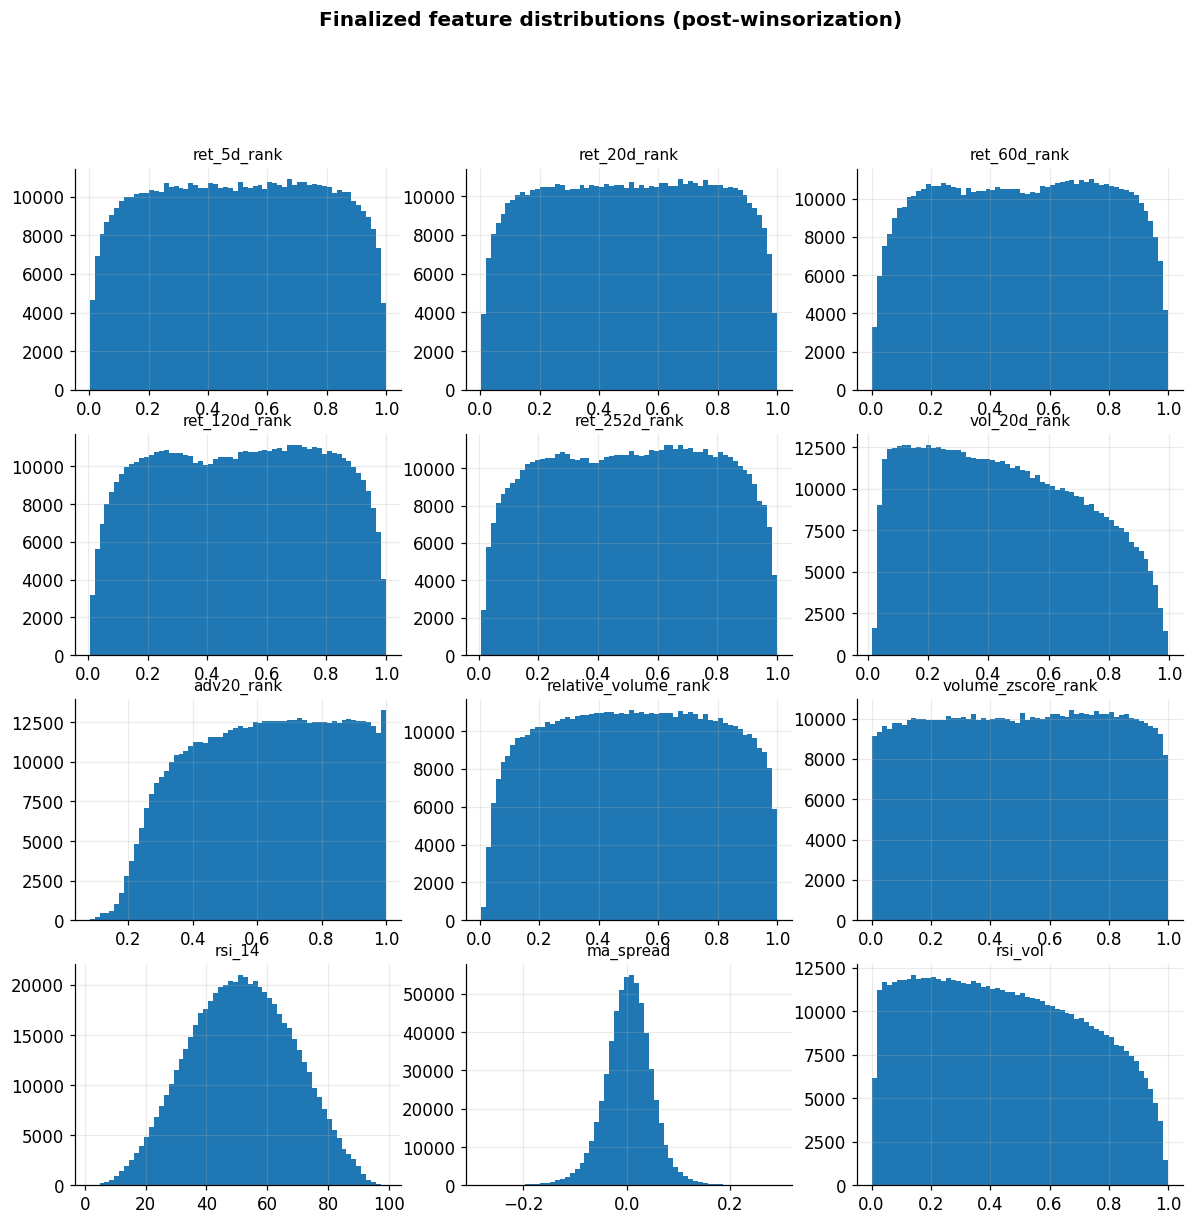

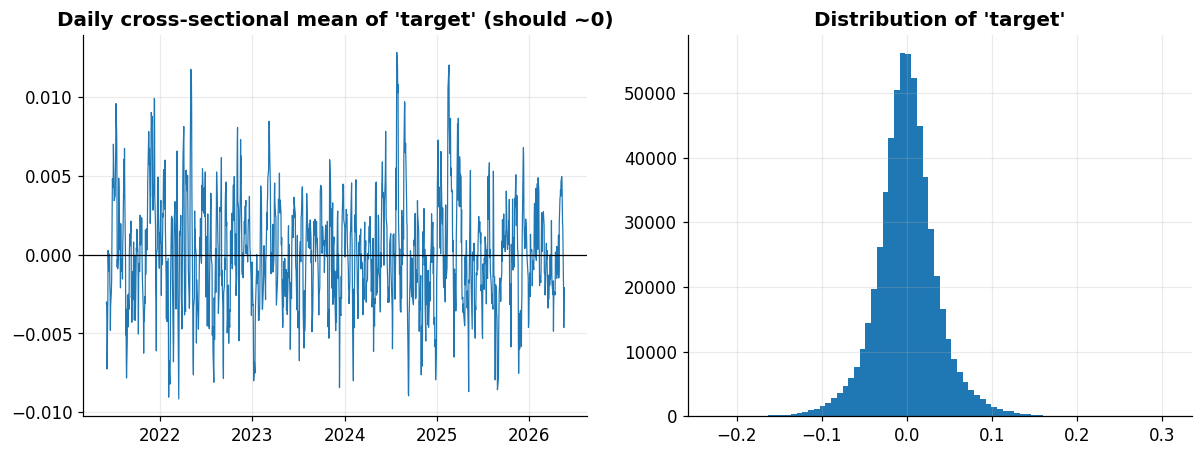

[ok]   universe size (membership flag col = in_index)
[ok]   survivorship coverage
[ok]   coverage heatmap (6, 38)
[ok]   observations per date
[ok]   feature correlation (38 features)
[ok]   feature distributions (12 shown)
[ok]   target sanity (target column assumed = 'target')

Figures saved to ./Results/


In [14]:
# ============================================================
# PRESENTATION FIGURES — data-hygiene visuals
# Run AFTER your existing cells (needs: membership, md_raw, universe,
# removed_tickers, model_df, feature_cols, by_year)
# Renders inline + saves PNGs to ./Results/
# ============================================================
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (11, 5), "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "savefig.bbox": "tight",
})
OUT = "Results"
try: os.makedirs(OUT, exist_ok=True)
except Exception: OUT = None
def _save(fig, name):
    if OUT:
        try: fig.savefig(f"{OUT}/{name}.png")
        except Exception as e: print(f"   [save failed] {name}: {e}")

log = []
def ok(m):   log.append(f"[ok]   {m}")
def skip(m): log.append(f"[skip] {m}")

# ---- 1. Universe size over time (PIT membership) ----------------------
# ASSUMPTION: `membership` is either long (cols incl. 'date' + a boolean
# member flag) OR wide (date index x symbols, boolean/0-1). Handles both.
try:
    m = membership.copy()
    if "date" in getattr(m, "columns", []):
        flag_cols = [c for c in m.columns
                     if m[c].dropna().isin([0,1,True,False]).all() and c != "date"]
        if not flag_cols:
            raise ValueError("no boolean membership flag column found")
        fc = flag_cols[0]                      # <-- assumed membership flag
        counts = m.groupby("date")[fc].sum()
    else:                                       # wide matrix
        counts = m.fillna(0).astype(float).sum(axis=1)
        counts.index = pd.to_datetime(counts.index)
    counts = counts.sort_index()
    fig, ax = plt.subplots()
    ax.plot(counts.index, counts.values, lw=1.6)
    ax.set_title("Point-in-time universe size over time")
    ax.set_ylabel("# index members"); ax.set_xlabel("")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    _save(fig, "universe_size"); plt.show()
    ok(f"universe size (membership flag col = "
       f"{fc if 'fc' in dir() else 'wide-sum'})")
except Exception as e:
    skip(f"universe size: {e}")

# ---- 2. Survivorship / delisted coverage ------------------------------
try:
    got = set(md_raw.columns.get_level_values(0))
    n_req, n_got = len(set(universe)), len(got & set(universe))
    n_del, n_del_data = len(removed_tickers), len(removed_tickers & got)
    fig, ax = plt.subplots(figsize=(8,4.5))
    bars = ["Universe\nrequested","Universe\nwith data",
            "Delisted\n(total)","Delisted\nwith data"]
    vals = [n_req, n_got, n_del, n_del_data]
    b = ax.bar(bars, vals)
    for r,v in zip(b, vals): ax.text(r.get_x()+r.get_width()/2, v,
                                     str(v), ha="center", va="bottom")
    ax.set_title("Survivorship coverage")
    ax.set_ylabel("# tickers")
    _save(fig, "survivorship_coverage"); plt.show()
    ok("survivorship coverage")
except Exception as e:
    skip(f"survivorship: {e}")

# ---- 3. Feature coverage heatmap (by_year) ----------------------------
try:
    by = by_year.copy()
    if not isinstance(by, pd.DataFrame): raise ValueError("by_year not a DataFrame")
    arr = by.values.astype(float)
    fig, ax = plt.subplots(figsize=(min(1+0.5*by.shape[1],14),
                                    min(1+0.35*by.shape[0],14)))
    im = ax.imshow(arr, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(by.shape[1])); ax.set_xticklabels(by.columns, rotation=45, ha="right")
    ax.set_yticks(range(by.shape[0])); ax.set_yticklabels(by.index, fontsize=8)
    ax.set_title("Feature coverage (non-null rate)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="coverage")
    _save(fig, "feature_coverage"); plt.show()
    ok(f"coverage heatmap {by.shape}")
except Exception as e:
    skip(f"coverage heatmap (orientation may be flipped — transpose by_year if so): {e}")

# ---- 4. Observations per date -----------------------------------------
try:
    obs = model_df.groupby("date").size().sort_index()
    fig, ax = plt.subplots()
    ax.plot(obs.index, obs.values, lw=1.2)
    ax.set_title("Observations per trading date")
    ax.set_ylabel("# rows"); ax.xaxis.set_major_locator(mdates.YearLocator())
    _save(fig, "obs_per_date"); plt.show()
    ok("observations per date")
except Exception as e:
    skip(f"obs per date: {e}")

# ---- 5. Feature correlation matrix ------------------------------------
try:
    feats = [c for c in feature_cols if c in model_df.columns]
    C = model_df[feats].corr()
    fig, ax = plt.subplots(figsize=(min(1+0.4*len(feats),14),)*2)
    im = ax.imshow(C.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=90, fontsize=7)
    ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=7)
    ax.set_title("Feature correlation matrix")
    fig.colorbar(im, ax=ax, shrink=0.8)
    _save(fig, "feature_correlation"); plt.show()
    ok(f"feature correlation ({len(feats)} features)")
except Exception as e:
    skip(f"feature correlation: {e}")

# ---- 6. Feature distributions (finalized values) ----------------------
# NOTE: these are POST-winsorization values (what's in model_df). A true
# before/after needs the raw pre-finalize values, which finalize_dataset
# does not retain — so this shows the finalized distribution only.
try:
    feats = [c for c in feature_cols if c in model_df.columns][:12]
    n = len(feats); ncol = 3; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3*nrow))
    for ax, f in zip(np.ravel(axes), feats):
        ax.hist(model_df[f].dropna().values, bins=60)
        ax.set_title(f, fontsize=10, fontweight="normal")
    for ax in np.ravel(axes)[n:]: ax.axis("off")
    fig.suptitle("Finalized feature distributions (post-winsorization)",
                 fontweight="bold", y=1.0)
    _save(fig, "feature_distributions"); plt.show()
    ok(f"feature distributions ({n} shown)")
except Exception as e:
    skip(f"feature distributions: {e}")

# ---- 7. Target sanity: daily cross-sectional mean ~ 0 -----------------
# ASSUMPTION on target name: first column matching 'target'/'fwd'/'_y'
# that is numeric and NOT in feature_cols. Verify the picked name below.
try:
    cand = [c for c in model_df.columns
            if c not in feature_cols and c not in ("date","symbol")
            and any(k in c.lower() for k in ("target","fwd","_y","ret_1d"))
            and pd.api.types.is_numeric_dtype(model_df[c])]
    if not cand: raise ValueError("no target-like column auto-detected")
    tgt = cand[0]                               # <-- VERIFY this is your target
    daily_mean = model_df.groupby("date")[tgt].mean().sort_index()
    fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
    axes[0].plot(daily_mean.index, daily_mean.values, lw=0.8)
    axes[0].axhline(0, color="k", lw=0.8)
    axes[0].set_title(f"Daily cross-sectional mean of '{tgt}' (should ~0)")
    axes[0].xaxis.set_major_locator(mdates.YearLocator())
    axes[1].hist(model_df[tgt].dropna().values, bins=80)
    axes[1].set_title(f"Distribution of '{tgt}'")
    _save(fig, "target_sanity"); plt.show()
    ok(f"target sanity (target column assumed = '{tgt}')")
except Exception as e:
    skip(f"target sanity: {e}")

# ---- log ---------------------------------------------------------------
print("\n".join(log))
print(f"\nFigures saved to ./{OUT}/" if OUT else "\n(figure saving disabled)")

In [15]:
dm = model_df.groupby("date")["target"].mean()
bad = dm[dm.abs() > 0.5].sort_values()
print(f"contaminated days (|daily mean| > 0.5): {len(bad)}")
print(bad.head(10))

ext = model_df.loc[model_df["target"].abs() > 1.0, ["date","symbol","target"]]
print(f"\nimpossible target rows (|target| > 1.0): {len(ext)}")
print("by year:\n", ext["date"].dt.year.value_counts().sort_index())

# constant-shift signature: on bad days, are surviving targets ~all equal?
for d in bad.index[:4]:
    s = model_df.loc[model_df["date"]==d, "target"]
    print(f"{d.date()}  n={len(s)}  mean={s.mean():+.2f}  std={s.std():.3f}  "
          f"min={s.min():+.2f}  max={s.max():+.2f}")

contaminated days (|daily mean| > 0.5): 0
Series([], Name: target, dtype: float64)

impossible target rows (|target| > 1.0): 0
by year:
 Series([], Name: count, dtype: int64)


### Save Data

In [16]:
# wide (ticker, field) -> long (date, symbol, OHLCV)
frames = []
for t in md_raw.columns.get_level_values(0).unique():
    sub = md_raw[t].copy()          # this ticker's OHLCV frame
    sub["symbol"] = t
    sub["date"]   = sub.index
    frames.append(sub)

md_long = pd.concat(frames, ignore_index=True)
md_long["date"] = pd.to_datetime(md_long["date"])
md_long = md_long[["date", "symbol", "Open", "High", "Low", "Close", "Volume"]]

md_long.to_parquet("Data/md_raw_long.parquet", index=False)

In [17]:
short_vol.to_parquet("./Data/short_vol.parquet")
short_int.to_parquet("./Data/short_int.parquet")
fundamentals.to_parquet("./Data/fundamentals.parquet")
model_df.to_parquet("./Data/model_df.parquet")

In [6]:
import pandas as pd
short_vol = pd.read_parquet("./Data/short_vol.parquet")
short_int = pd.read_parquet("./Data/short_int.parquet")
fundamentals = pd.read_parquet("./Data/fundamentals.parquet")
short_vol.head()

,date,symbol,short_volume,total_volume_finra,short_ratio,short_ratio_z20,short_ratio_chg5
0,2021-01-04,A,112839.0,355723.0,0.317210,NaN,NaN
1,2021-01-05,A,150888.0,514747.0,0.293130,NaN,NaN
2,2021-01-06,A,129466.0,741660.0,0.174562,NaN,NaN
3,2021-01-07,A,145982.0,551947.0,0.264486,NaN,NaN
4,2021-01-08,A,84017.0,389459.0,0.215727,NaN,NaN


In [8]:
fundamentals.head()

,date,revenue,net_income,eps_diluted,assets,equity,symbol
0,2021-01-04,5.339000e+09,199000000.0,2.3,9.627000e+09,4.873000e+09,A
1,2021-01-05,5.339000e+09,199000000.0,2.3,9.627000e+09,4.873000e+09,A
2,2021-01-06,5.339000e+09,199000000.0,2.3,9.627000e+09,4.873000e+09,A
3,2021-01-07,5.339000e+09,199000000.0,2.3,9.627000e+09,4.873000e+09,A
4,2021-01-08,5.339000e+09,199000000.0,2.3,9.627000e+09,4.873000e+09,A
